In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns",None)

print("Libraries Imported Successfully ✅")

Libraries Imported Successfully ✅


In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (9).zip to archive (9).zip


In [3]:
import zipfile
import os

zip_file = "archive (9).zip"

extract_path = "/content/dataset"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted successfully!")

Files extracted successfully!


In [4]:
import os

os.listdir('/content/dataset')

['Folds5x2_pp.csv']

In [5]:
df = pd.read_csv('/content/dataset/Folds5x2_pp.csv')
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
print("Shape :",df.shape)

print("\nRows :",df.shape[0])

print("\nColumns :",df.shape[1])

Shape : (9568, 5)

Rows : 9568

Columns : 5


In [8]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [9]:
df.columns=[
    "Ambient_Temperature",
    "Exhaust_Vacuum",
    "Ambient_Pressure",
    "Relative_Humidity",
    "Energy_Output"
]

df.head()

,Ambient_Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Output
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Ambient_Temperature  9568 non-null   float64
 1   Exhaust_Vacuum       9568 non-null   float64
 2   Ambient_Pressure     9568 non-null   float64
 3   Relative_Humidity    9568 non-null   float64
 4   Energy_Output        9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Ambient_Temperature,9568.0,19.651231,7.452473,1.81,13.5100,20.345,25.72,37.11
Exhaust_Vacuum,9568.0,54.305804,12.707893,25.36,41.7400,52.080,66.54,81.56
Ambient_Pressure,9568.0,1013.259078,5.938784,992.89,1009.1000,1012.940,1017.26,1033.30
Relative_Humidity,9568.0,73.308978,14.600269,25.56,63.3275,74.975,84.83,100.16
Energy_Output,9568.0,454.365009,17.066995,420.26,439.7500,451.550,468.43,495.76


In [12]:
df.isnull().sum()

,0
Ambient_Temperature,0
Exhaust_Vacuum,0
Ambient_Pressure,0
Relative_Humidity,0
Energy_Output,0


In [13]:
print("Duplicate Rows :",df.duplicated().sum())

Duplicate Rows : 41


In [14]:
df=df.drop_duplicates()

print(df.shape)

(9527, 5)


In [15]:
df.dtypes

,0
Ambient_Temperature,float64
Exhaust_Vacuum,float64
Ambient_Pressure,float64
Relative_Humidity,float64
Energy_Output,float64


In [16]:
for col in df.columns:
    print(col)
    print(df[col].nunique())
    print("-"*30)

Ambient_Temperature
2773
------------------------------
Exhaust_Vacuum
634
------------------------------
Ambient_Pressure
2517
------------------------------
Relative_Humidity
4546
------------------------------
Energy_Output
4836
------------------------------


<Figure size 1500x800 with 0 Axes>

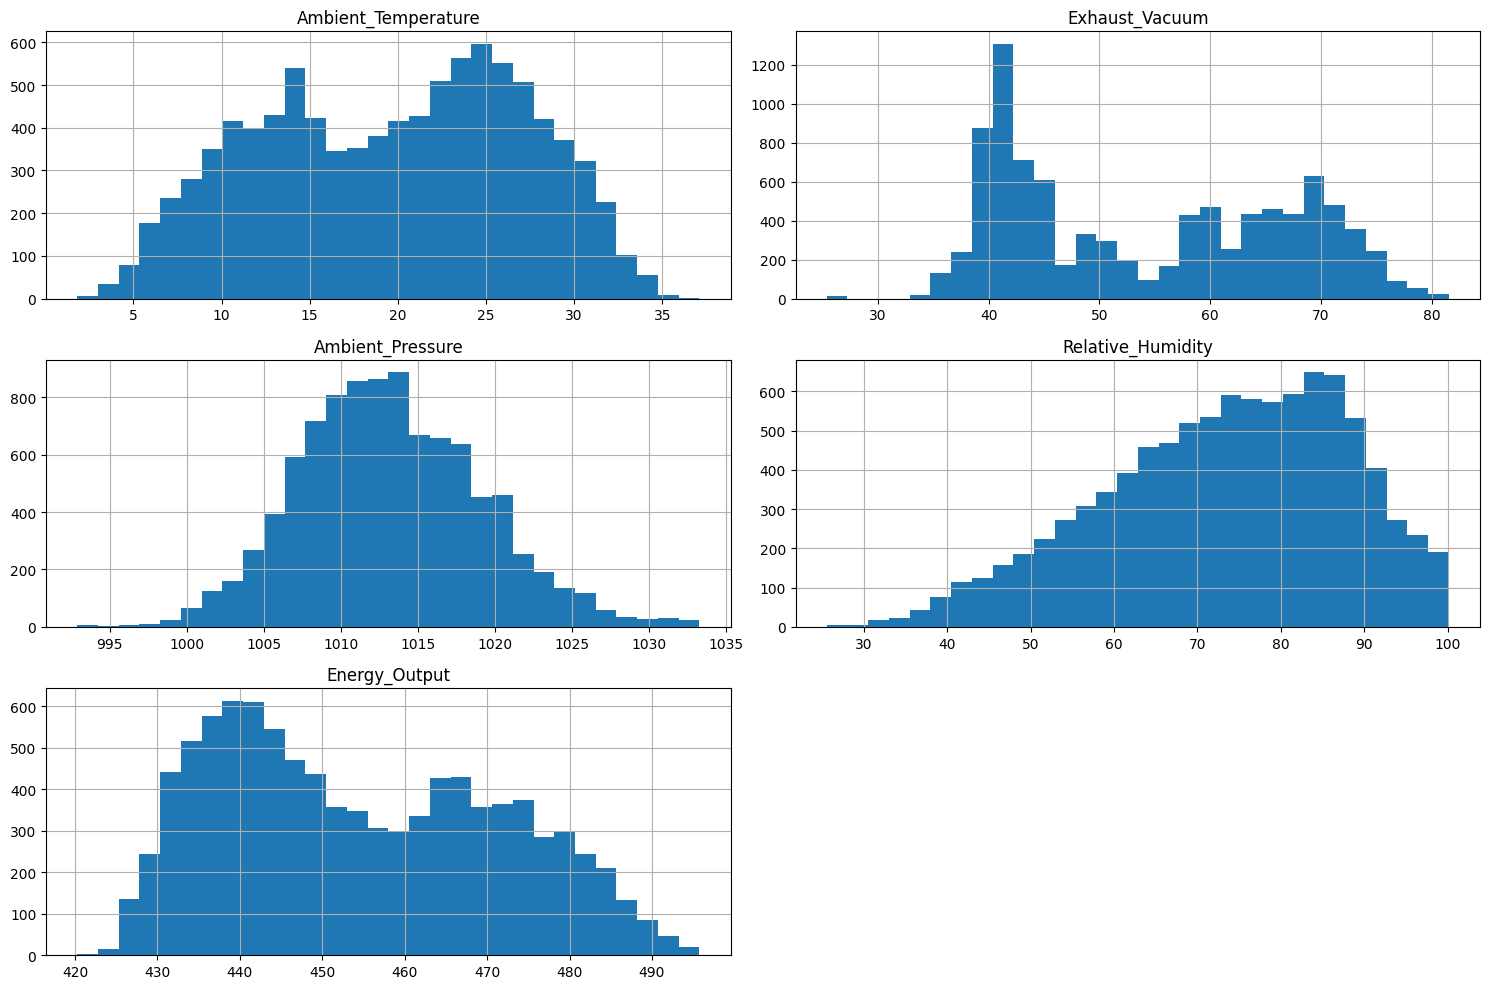

In [17]:
plt.figure(figsize=(15,8))

df.hist(
    bins=30,
    figsize=(15,10)
)

plt.tight_layout()

plt.show()

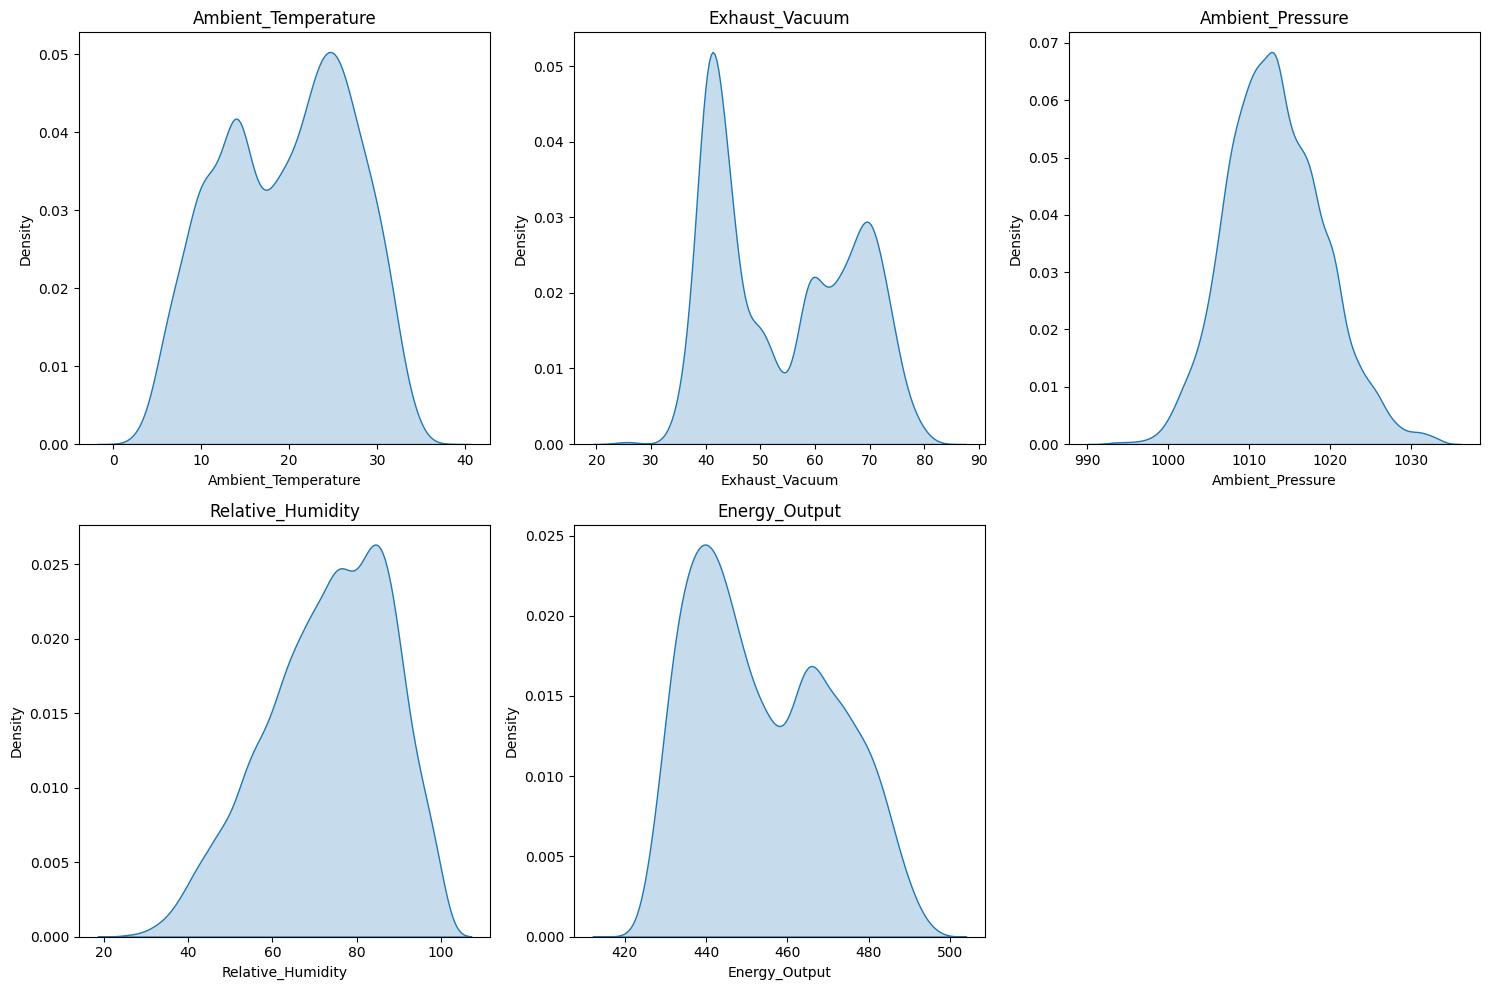

In [18]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns):

    plt.subplot(2,3,i+1)

    sns.kdeplot(df[col],fill=True)

    plt.title(col)

plt.tight_layout()

plt.show()

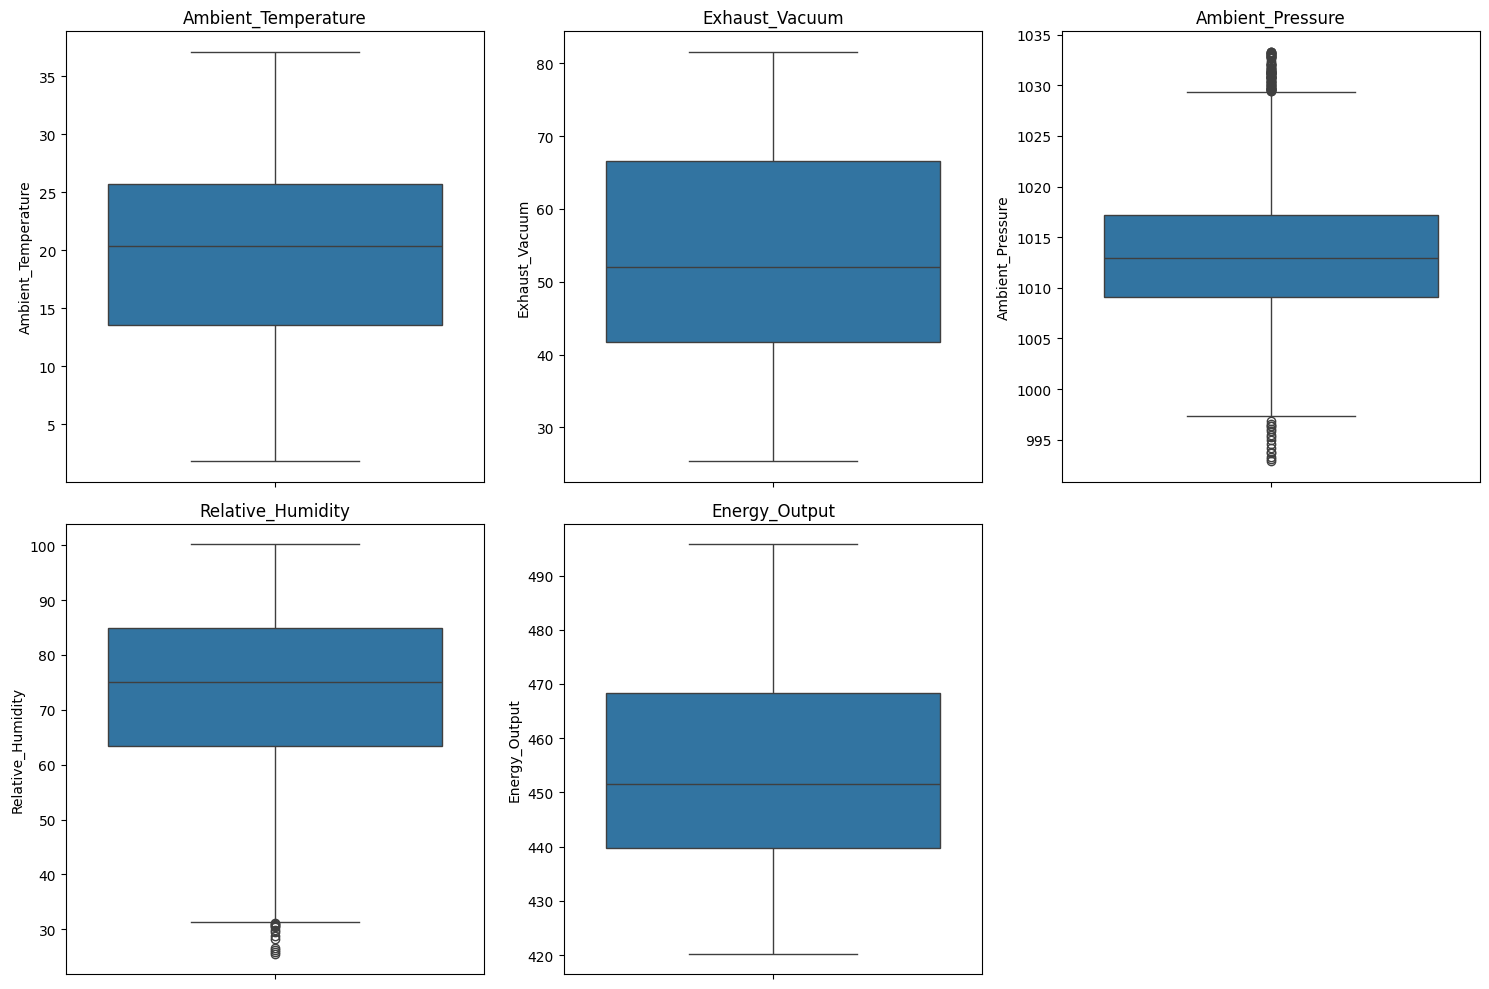

In [19]:
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns):

    plt.subplot(2,3,i+1)

    sns.boxplot(y=df[col])

    plt.title(col)

plt.tight_layout()

plt.show()

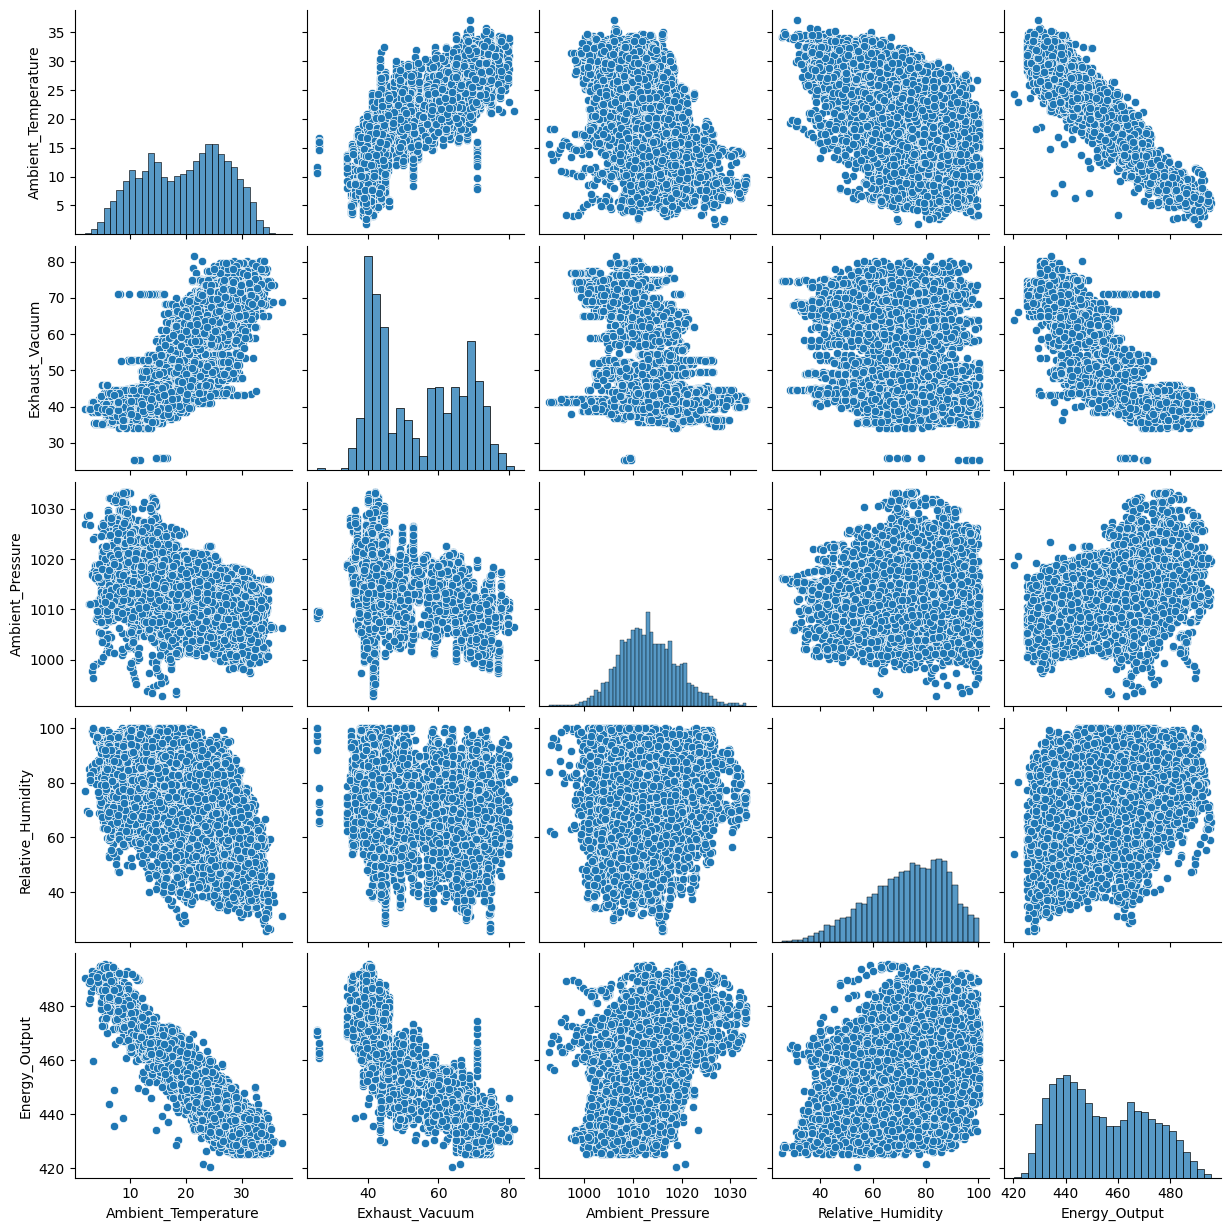

In [20]:
sns.pairplot(df)

plt.show()

In [21]:
corr=df.corr()

corr

,Ambient_Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity,Energy_Output
Ambient_Temperature,1.000000,0.843689,-0.508222,-0.543947,-0.947908
Exhaust_Vacuum,0.843689,1.000000,-0.415718,-0.312214,-0.869900
Ambient_Pressure,-0.508222,-0.415718,1.000000,0.101631,0.518687
Relative_Humidity,-0.543947,-0.312214,0.101631,1.000000,0.391175
Energy_Output,-0.947908,-0.869900,0.518687,0.391175,1.000000


<Figure size 800x500 with 0 Axes>

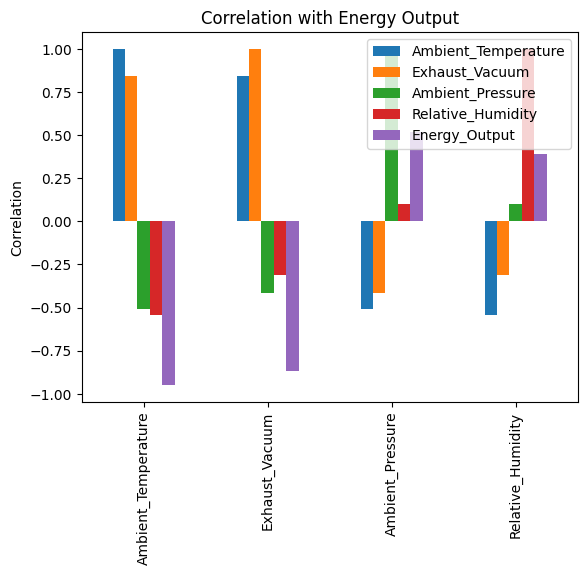

In [22]:
plt.figure(figsize=(8,5))

corr.drop("Energy_Output").plot(kind="bar")

plt.ylabel("Correlation")

plt.title("Correlation with Energy Output")

plt.show()

In [23]:
X = df.drop("Energy_Output", axis=1)

y = df["Energy_Output"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (9527, 4)
Target Shape : (9527,)


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Samples :", X_train.shape)
print("Testing Samples :", X_test.shape)

Training Samples : (7621, 4)
Testing Samples : (1906, 4)


In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet

from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)

from sklearn.neighbors import KNeighborsRegressor

from sklearn.svm import SVR

In [27]:
models = {

    "Linear Regression":LinearRegression(),

    "Ridge":Ridge(),

    "Lasso":Lasso(),

    "Elastic Net":ElasticNet(),

    "Decision Tree":DecisionTreeRegressor(random_state=42),

    "Random Forest":RandomForestRegressor(random_state=42),

    "Extra Trees":ExtraTreesRegressor(random_state=42),

    "Gradient Boosting":GradientBoostingRegressor(random_state=42),

    "AdaBoost":AdaBoostRegressor(random_state=42),

    "KNN":KNeighborsRegressor(),

    "SVR":SVR()

}

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [29]:
results = []

for name, model in models.items():

    if name in ["SVR", "KNN"]:
        model.fit(X_train_scaled, y_train)
        prediction = model.predict(X_test_scaled)

    else:
        model.fit(X_train, y_train)
        prediction = model.predict(X_test)

    mae = mean_absolute_error(y_test, prediction)

    mse = mean_squared_error(y_test, prediction)

    rmse = np.sqrt(mse)

    r2 = r2_score(y_test, prediction)

    n = len(y_test)
    p = X_test.shape[1]

    adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

    results.append([
        name,
        mae,
        mse,
        rmse,
        r2,
        adjusted_r2
    ])

In [30]:
result_df = pd.DataFrame(

    results,

    columns=[

        "Model",

        "MAE",

        "MSE",

        "RMSE",

        "R2 Score",

        "Adjusted R2"

    ]

)

result_df = result_df.sort_values(
    by="R2 Score",
    ascending=False
)

result_df

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
5,Random Forest,2.329783,10.519427,3.243367,0.965143,0.965070
6,Extra Trees,2.325949,10.832358,3.291255,0.964106,0.964031
7,Gradient Boosting,2.917625,14.407746,3.795754,0.952259,0.952159
9,KNN,2.765866,14.448666,3.801140,0.952123,0.952023
10,SVR,3.188467,17.356889,4.166160,0.942487,0.942366
4,Decision Tree,3.110614,20.188315,4.493141,0.933105,0.932964
0,Linear Regression,3.662981,20.892789,4.570863,0.930770,0.930625
1,Ridge,3.662985,20.892824,4.570867,0.930770,0.930625
2,Lasso,3.679887,21.058511,4.588955,0.930221,0.930074
3,Elastic Net,3.697380,21.220851,4.606610,0.929683,0.929535


In [31]:
best_model_name = result_df.iloc[0]["Model"]

print(" Best Model :", best_model_name)

 Best Model : Random Forest


In [32]:
print(result_df.head())

                Model       MAE        MSE      RMSE  R2 Score  Adjusted R2
5       Random Forest  2.329783  10.519427  3.243367  0.965143     0.965070
6         Extra Trees  2.325949  10.832358  3.291255  0.964106     0.964031
7   Gradient Boosting  2.917625  14.407746  3.795754  0.952259     0.952159
9                 KNN  2.765866  14.448666  3.801140  0.952123     0.952023
10                SVR  3.188467  17.356889  4.166160  0.942487     0.942366


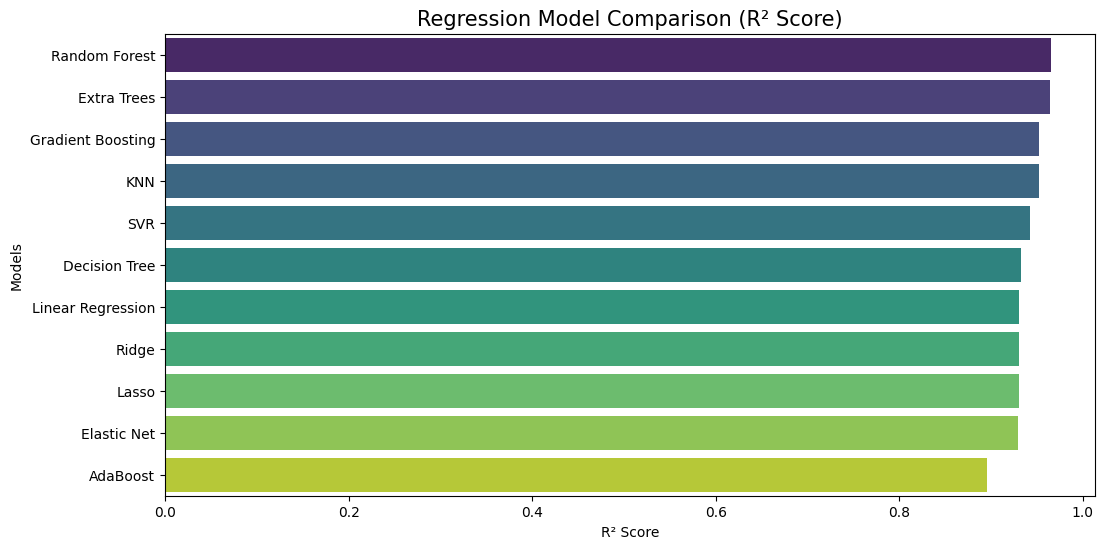

In [33]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=result_df,
    x="R2 Score",
    y="Model",
    palette="viridis"
)

plt.title("Regression Model Comparison (R² Score)", fontsize=15)

plt.xlabel("R² Score")

plt.ylabel("Models")

plt.show()

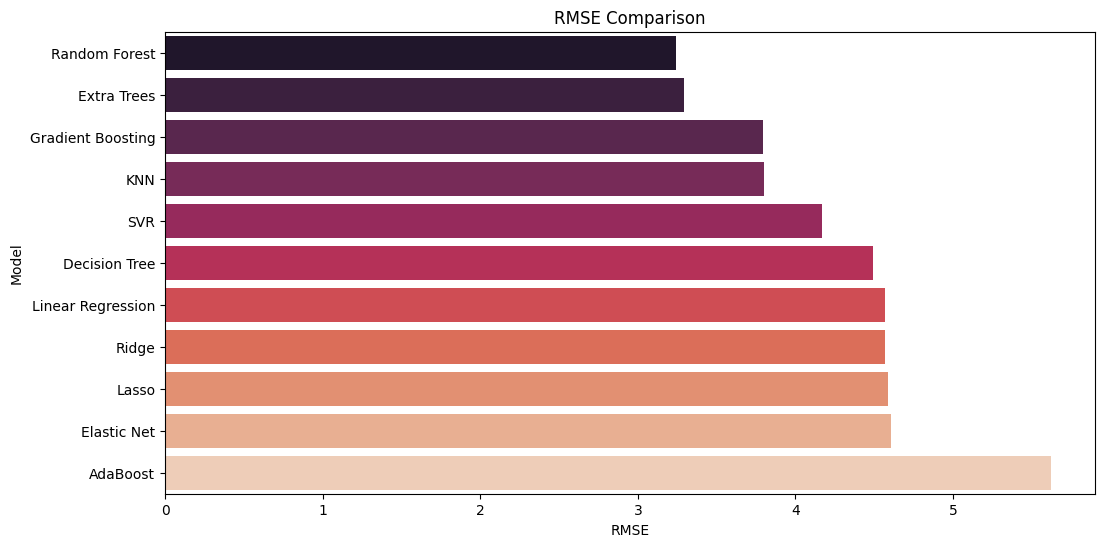

In [34]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=result_df,
    x="RMSE",
    y="Model",
    palette="rocket"
)

plt.title("RMSE Comparison")

plt.show()

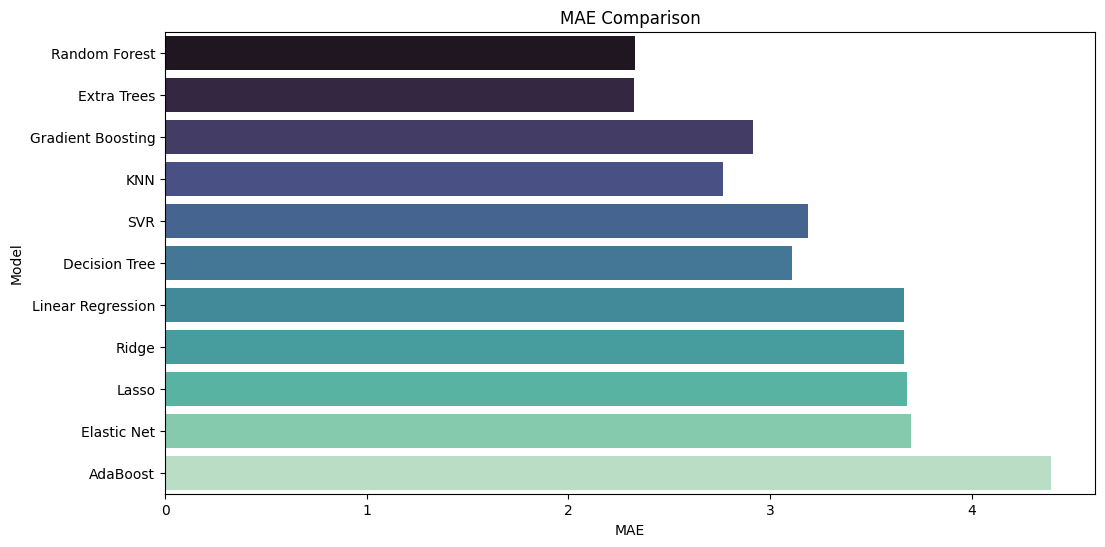

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=result_df,
    x="MAE",
    y="Model",
    palette="mako"
)

plt.title("MAE Comparison")

plt.show()

In [36]:
from sklearn.model_selection import cross_val_score

rf = RandomForestRegressor(random_state=42)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print("Cross Validation Scores:\n")
print(scores)

print("\nAverage CV Score:",scores.mean())

Cross Validation Scores:

[0.96243681 0.95333352 0.96445164 0.96232705 0.9638806 ]

Average CV Score: 0.9612859234075335


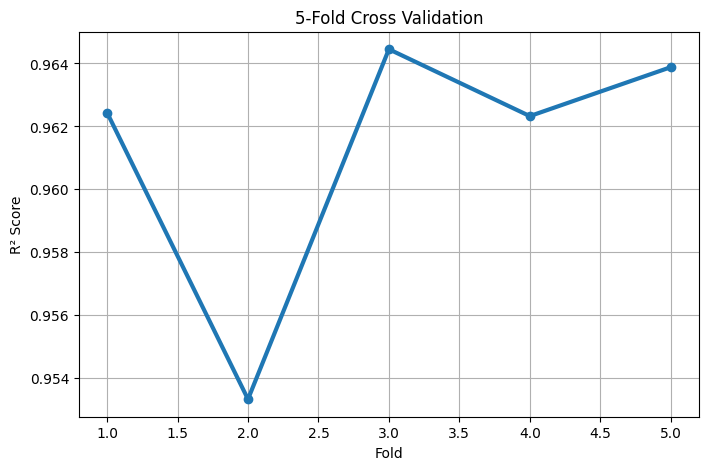

In [37]:
plt.figure(figsize=(8,5))

plt.plot(range(1,6),scores,
         marker='o',
         linewidth=3)

plt.title("5-Fold Cross Validation")

plt.xlabel("Fold")

plt.ylabel("R² Score")

plt.grid(True)

plt.show()

In [38]:
from sklearn.model_selection import GridSearchCV

params = {

    "n_estimators":[100,200],

    "max_depth":[10,20,None],

    "min_samples_split":[2,5],

    "min_samples_leaf":[1,2]

}

grid = GridSearchCV(

    estimator=RandomForestRegressor(random_state=42),

    param_grid=params,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [39]:
print("Best Parameters:\n")

print(grid.best_params_)

Best Parameters:

{'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [40]:
best_model = grid.best_estimator_

prediction = best_model.predict(X_test)

print("R² Score :",r2_score(y_test,prediction))

R² Score : 0.965497969164759


In [41]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

importance

,Feature,Importance
0,Ambient_Temperature,0.895199
1,Exhaust_Vacuum,0.067440
2,Ambient_Pressure,0.019686
3,Relative_Humidity,0.017674


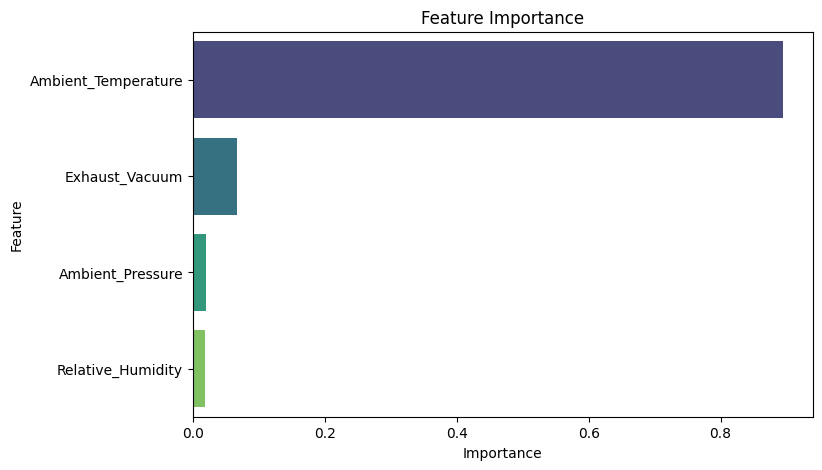

In [42]:
plt.figure(figsize=(8,5))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Feature Importance")

plt.show()

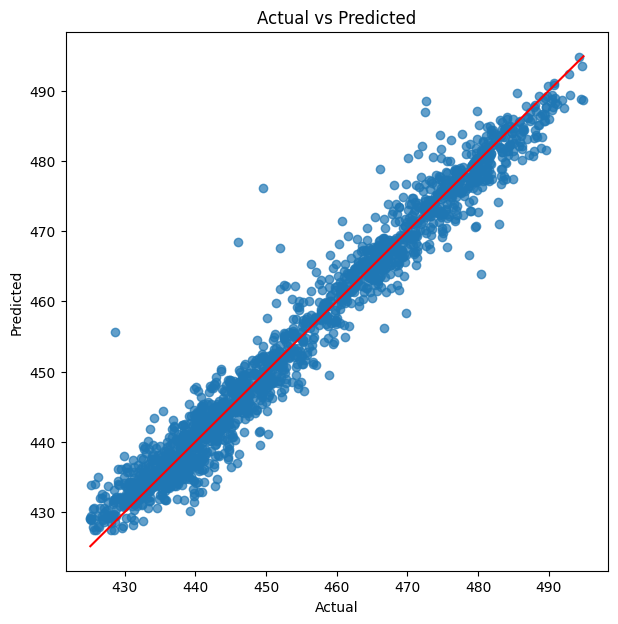

In [44]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    prediction,

    alpha=0.7

)

plt.plot(

    [y_test.min(),y_test.max()],

    [y_test.min(),y_test.max()],

    color='red'

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted")

plt.show()

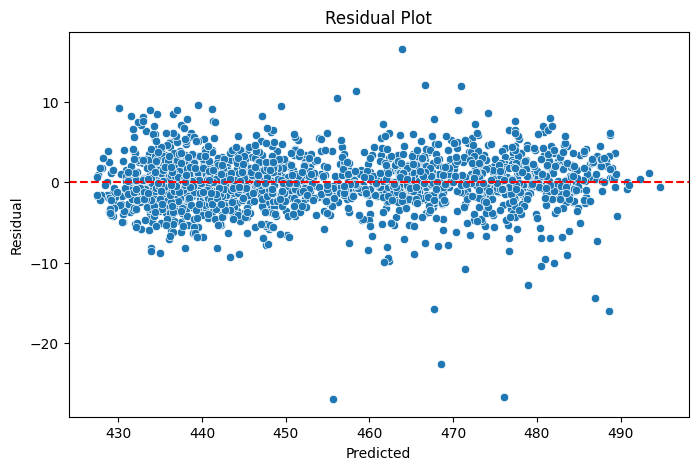

In [45]:
residual = y_test-prediction

plt.figure(figsize=(8,5))

sns.scatterplot(

    x=prediction,

    y=residual

)

plt.axhline(

    y=0,

    color="red",

    linestyle="--"

)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

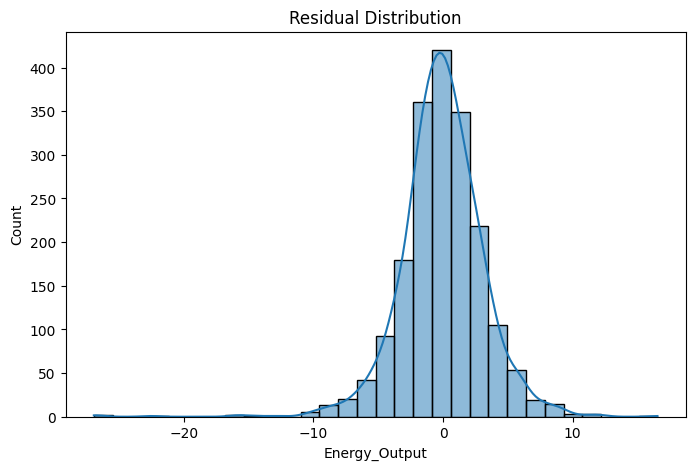

In [46]:
plt.figure(figsize=(8,5))

sns.histplot(

    residual,

    kde=True,

    bins=30

)

plt.title("Residual Distribution")

plt.show()

In [47]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

print("MAE :",mean_absolute_error(y_test,prediction))

print("RMSE :",np.sqrt(mean_squared_error(y_test,prediction)))

print("R² :",r2_score(y_test,prediction))

MAE : 2.3183796059249535
RMSE : 3.2268182116124686
R² : 0.965497969164759


In [48]:
import joblib

joblib.dump(best_model,"Best_RandomForest_Model.pkl")

['Best_RandomForest_Model.pkl']

In [49]:
loaded_model = joblib.load("Best_RandomForest_Model.pkl")

In [50]:
new_data = pd.DataFrame({

    "Ambient_Temperature":[15],

    "Exhaust_Vacuum":[45],

    "Ambient_Pressure":[1015],

    "Relative_Humidity":[60]

})

pred = loaded_model.predict(new_data)

print("Predicted Energy Output =",pred[0],"MW")

Predicted Energy Output = 464.1920527777778 MW


In [51]:
result_df = result_df.sort_values("R2 Score", ascending=False)

result_df.style\
.background_gradient(cmap="Greens", subset=["R2 Score"])\
.background_gradient(cmap="Reds_r", subset=["RMSE"])\
.background_gradient(cmap="Blues_r", subset=["MAE"])\
.format({
    "MAE":"{:.3f}",
    "RMSE":"{:.3f}",
    "R2 Score":"{:.4f}",
    "Adjusted R2":"{:.4f}"
})

,Model,MAE,MSE,RMSE,R2 Score,Adjusted R2
5,Random Forest,2.330,10.519427,3.243,0.9651,0.9651
6,Extra Trees,2.326,10.832358,3.291,0.9641,0.9640
7,Gradient Boosting,2.918,14.407746,3.796,0.9523,0.9522
9,KNN,2.766,14.448666,3.801,0.9521,0.9520
10,SVR,3.188,17.356889,4.166,0.9425,0.9424
4,Decision Tree,3.111,20.188315,4.493,0.9331,0.9330
0,Linear Regression,3.663,20.892789,4.571,0.9308,0.9306
1,Ridge,3.663,20.892824,4.571,0.9308,0.9306
2,Lasso,3.680,21.058511,4.589,0.9302,0.9301
3,Elastic Net,3.697,21.220851,4.607,0.9297,0.9295


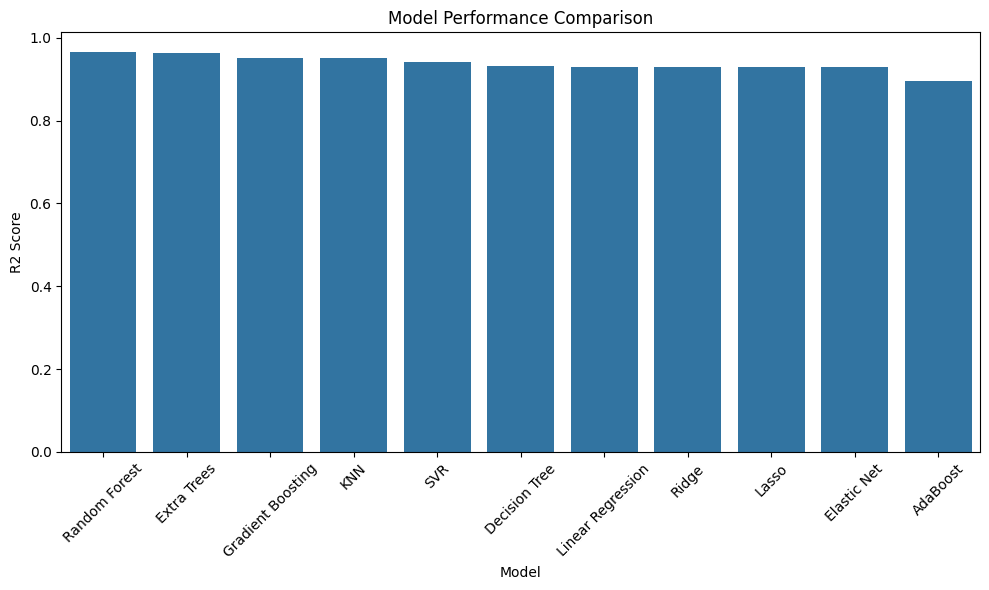

In [52]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=result_df,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=45)

plt.title("Model Performance Comparison")

plt.tight_layout()

plt.show()